In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import Tensor
import time

In [42]:
def sigma(z):
    return 1 / (1 + np.exp(-z))

def smooth_round_precise(x, k):
    result = np.zeros_like(x)
    for i in range(len(x)):
        xi = x[i]
        n0 = np.floor(xi)
        neighbors = np.array([n0-1, n0, n0+1, n0+2])
        rhos = (
            k * sigma(k * (xi - neighbors)) *
            (1 - sigma(k * (xi - neighbors)))
        )
        numerator = np.sum(neighbors * rhos)
        denominator = np.sum(rhos) + 1e-8
        result[i] = numerator / denominator
    return result

def classical_round(x):
    return np.round(x)

def round_sigma_derivative_normalized(x, k):
    numerator = np.zeros_like(x)
    denominator = np.zeros_like(x)
    for i in range(len(x)):
        xi = x[i]
        n_range = np.arange(np.floor(xi) - 2, np.floor(xi) + 3)
        for n in n_range:
            rho = k * sigma(k * (xi - n)) * (1 - sigma(k * (xi - n)))
            numerator[i] += n * rho
            denominator[i] += rho
    denominator = np.maximum(denominator, 1e-8)
    return numerator / denominator

def round_sigma_original(x, k):
    result = np.zeros_like(x)
    for i in range(len(x)):
        xi = x[i]
        n_range = np.arange(np.floor(xi) - 2, np.floor(xi) + 3)
        for n in n_range:
            result[i] += n * (
                sigma(k * (xi - (n - 0.5)))
                - sigma(k * (xi - (n + 0.5)))
            )
    return result

def round_sigma_original_2(x, k):
    result = np.zeros_like(x)
    n_range = np.arange(-2, 3)
    for i in range(len(x)):
        xi = x[i]
        floored = np.floor(xi)
        fractal = xi - floored
        # print(fractal)
        for n in n_range:
            result[i] += (floored - n) * (
                sigma(k * (fractal + n + 0.5))
                - sigma(k * (fractal + n - 0.5))
            )
    return result

In [95]:
def torch_round_sigma(x: Tensor, k) -> Tensor:
    base_range = torch.arange(-2, 3)

    floored = x.floor()
    frac = x - floored
    k_half = k * .5
    k_frac_plus_n = (frac[:, None] + base_range) * k
    # print(k_frac_plus_n.shape)
    floored_minus_n = floored[:, None] - base_range
    # print(floored_minus_n.shape)
    zwerg = torch.sigmoid(k_frac_plus_n + k_half) - torch.sigmoid(k_frac_plus_n - k_half)
    return (floored_minus_n * zwerg).sum(dim=-1)

In [96]:
torch_round_sigma(torch.arange(0.3, 10.8, step=0.3), 2)

tensor([ 0.2730,  0.5374,  0.7799,  1.1680,  1.4305,  1.6689,  2.0641,  2.3271,
         2.5650,  2.9598,  3.2256,  3.4657,  3.6590,  4.1247,  4.3692,  4.5679,
         5.0231,  5.2737,  5.4802,  5.9197,  6.1781,  6.3940,  6.5382,  7.0813,
         7.3078,  7.4669,  7.9822,  8.2203,  8.3954,  8.8795,  9.1307,  9.3223,
         9.4174, 10.0380, 10.2464])

In [43]:
k = 20
x = np.linspace(-1, 1, 1000)

In [90]:
functions = [classical_round, lambda x: torch_round_sigma(torch.from_numpy(x), k), lambda x: round_sigma_original_2(x, k)]
times = []
for f in functions:
    start = time.time()
    for m in range(100):
        x = np.linspace(m - 10, m + 10, 1000)
        y_f = f(x)
    end = time.time()
    times.append(end - start)
times

[0.0008504390716552734, 0.005317211151123047, 0.39894962310791016]

In [97]:
y_classical = classical_round(x)
y_original = round_sigma_original(x, k)
y_normalized = round_sigma_derivative_normalized(x, k)
y_my = round_sigma_original_2(x, k)
y_torch = torch_round_sigma(torch.from_numpy(x), k)

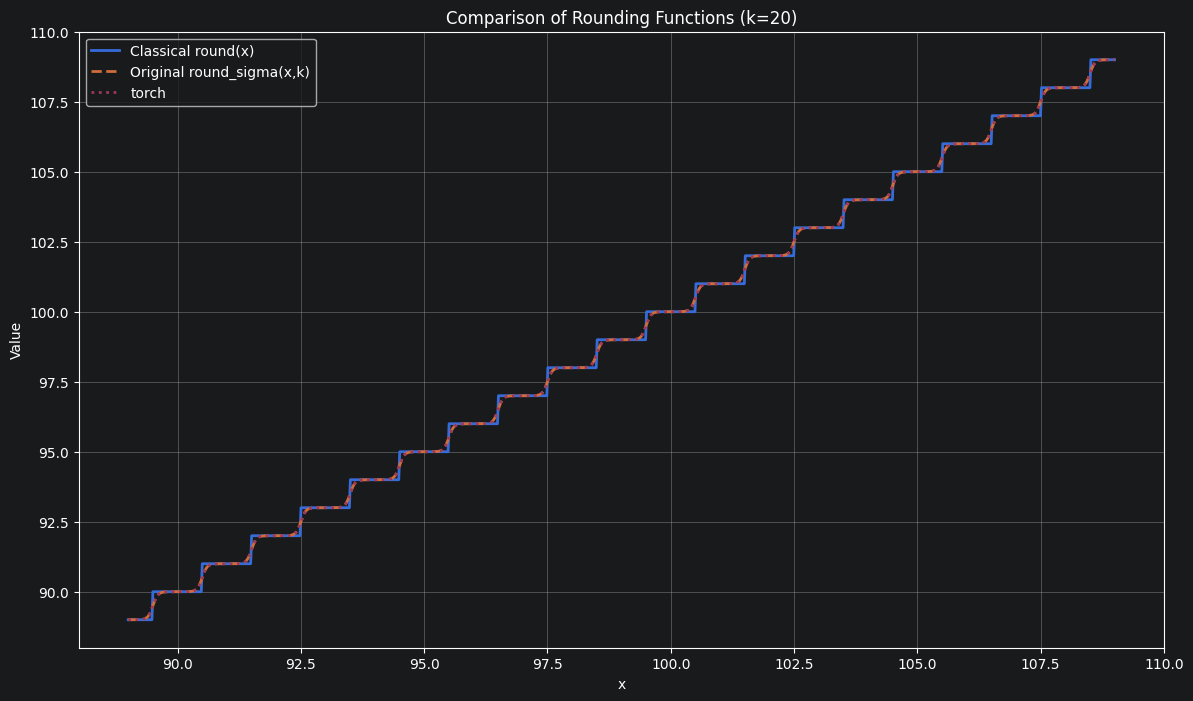

In [98]:
plt.figure(figsize=(14, 8))
plt.plot(
    x, y_classical,
    label="Classical round(x)",
    linestyle="-",
    linewidth=2
)
plt.plot(
    x, y_original,
    label="Original round_sigma(x,k)",
    linestyle="--",
    linewidth=2
)
# plt.plot(
#     x, y_normalized,
#     label="Normalized derivative approximation",
#     linestyle="-.",
#     linewidth=2
# )
# plt.plot(
#     x, y_my,
#     label="my option",
#     linestyle="dotted",
#     linewidth=2
# )
plt.plot(
    x, y_torch,
    label="torch",
    linestyle="dotted",
    linewidth=2
)
plt.title(f"Comparison of Rounding Functions (k={k})")
plt.xlabel("x")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()